In [1]:
# 산탄데르 은행 고객 데이터로 만족 예측 모델 프로젝트
# 피쳐 : 370개
# 원래답 : 1(불만족), 0(만족)
# 이 예제로 무엇을 학습 목표
# 1. 불균형 데이터 처리
# 2. info(), describe() => 위장된 결측치
# 3. AUC
# 4. HyperOpt, Kfold
# 5. XGB, LGBM


In [2]:
# 모델 파이프라인
# 1. 데이터로딩 2. 불균형확인 3. 이상값 탐지 4.전처리 5.3단계 분할 6. XGB 학습 7. HyperOpt 튜닝 8. LGBM

In [3]:
# numpy : 수치 연산(배열, 행렬 계산 등)을 위한 라이브러리 임포트
import numpy as np
# pandas : 데이터프레임 기반 데이터 처리/분석 라이브러리 임포트
import pandas as pd
# matplotlib.pyplot : 그래프/시각화를 위한 모듈 임포트
import matplotlib.pyplot as plt
# matplotlib : 시각화 설정(폰트 등)을 위해 matplotlib 자체도 임포트
import matplotlib
# warnings : 경고 메시지 제어를 위한 표준 라이브러리 임포트
import warnings
# warnings.filterwarnings('ignore') : 실행 중 발생하는 경고 메시지를 화면에 출력하지 않도록 설정
warnings.filterwarnings('ignore')


# 1. 데이터 로딩(5초)
# dataset shape: (76020 rows, 371 columns)

# pd.read_csv(경로, encoding='latin-1') : 지정 경로의 csv 파일을 읽어 데이터프레임으로 로드
#   - encoding='latin-1' : 파일 인코딩을 latin-1(서유럽어 인코딩)으로 지정하여 인코딩 오류 방지
cust_df = pd.read_csv("../data/santander-customer-satisfaction/train.csv", encoding='latin-1')

# cust_df.shape : (행 개수, 열 개수) 튜플 반환 → 로드된 데이터 크기 확인
print('dataset shape:', cust_df.shape)

# cust_df.head(30) : 데이터프레임의 상위 30개 행을 출력하여 데이터 내용을 미리 확인
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [4]:
# info() : 전체 데이터 구조파악
cust_df.info()

# cust_df.info() : 데이터프레임의 전반적인 구조 정보를 출력
#   - 전체 행/열 개수(RangeIndex, columns)
#   - 각 컬럼명, 컬럼별 결측치 아닌 값의 개수(Non-Null Count)
#   - 각 컬럼의 데이터 타입(Dtype: int64, float64, object 등)
#   - 메모리 사용량(memory usage)
#   → 결측치 유무, 데이터 타입 오류 여부 등을 빠르게 파악하는 데 사용

<class 'pandas.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [5]:
# 분류 문제 첫번째 레이블(답) 불균형 확인(96:4 비율) 
# 이런경우 정확도는 의미가 없다. AUC를 사용해야 한다.
# 이런경우 AUC 점수로 모델의 성능을 평가한다.

# cust_df['TARGET'].value_counts() : TARGET 컬럼의 각 값(0, 1)이 몇 개씩 있는지 개수를 세어 반환 (내림차순 정렬)
print(cust_df['TARGET'].value_counts())

# cust_df[cust_df['TARGET'] == 1] : TARGET 값이 1인 행만 필터링 (불만족 고객)
# .TARGET.count() : 필터링된 결과에서 TARGET 컬럼의 개수(결측치 제외)를 셈 → 불만족 고객 수
unsatisfied_cnt = cust_df[cust_df['TARGET'] == 1].TARGET.count()

# cust_df.TARGET.count() : 전체 TARGET 컬럼의 개수(결측치 제외) → 전체 고객 수
total_cnt = cust_df.TARGET.count()

# unsatisfied_cnt / total_cnt : 전체 중 불만족 고객이 차지하는 비율 계산
# '{0:.2f}'.format(...) : 소수점 둘째 자리까지 반올림하여 문자열에 삽입
print('unsatisfied 비율은xx {0:.2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은xx 0.04


In [6]:
# 기본통계
cust_df.describe()

# cust_df.describe() : 데이터프레임의 수치형 컬럼들에 대한 기본 통계량을 요약해서 반환
#   - count(결측치 제외 개수), mean(평균), std(표준편차), min(최솟값)
#   - 25%, 50%(중앙값), 75% (사분위수)
#   - max(최댓값)
#   → 각 컬럼별로 이 통계량들이 표(DataFrame) 형태로 출력되어, 데이터의 분포와 이상치 여부를 한눈에 파악하는 데 사용

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [7]:
cust_df['var3'].value_counts()
# -999999      116 => NaN

# cust_df['var3'].value_counts() : 'var3' 컬럼에서 각 값(고유값)이 몇 번 등장하는지 개수를 세어 반환 (내림차순 정렬)
#   - 아래 주석은 그 결과 중 하나를 메모한 것: -999999라는 값이 116개 있고, 이는 실제 값이 아니라 결측치(NaN)를 의미하는 특수 코드값이라는 뜻

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
           ...  
 63            1
 194           1
 40            1
 57            1
 87            1
Name: count, Length: 208, dtype: int64

In [8]:
# var3 , id

# cust_df['var3'] : cust_df 데이터프레임에서 'var3' 컬럼(Series)을 선택

# .replace(-999999, 2) : 값 치환 함수
#   - 첫 번째 인자(-999999) : 치환 대상이 되는 원래 값
#   - 두 번째 인자(2)       : 치환할 새로운 값
#   - 'var3' 컬럼 내에서 이상치(결측 표시용 특수값)로 쓰인 -999999를 2로 변경
#   → -999999는 실제 값이 아니라 결측치를 나타내는 코드값으로 추정되며, 최빈값 등으로 대체하는 전처리 작업
cust_df['var3'] = cust_df['var3'].replace(-999999, 2)

In [9]:
# id 삭제, inplace=False로 해야 cust_df에 반영되지 않는다. 복사본으로 처리해라.
cust_df.drop('ID', axis=1, inplace=True)

In [10]:
cust_df.describe()

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,2.716483,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,3.160715,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,9.447971,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,95.268204,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,8237.820000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [11]:
# 데이터와 레이블 분리
# 데이터 컬럼전체(370개)에서 마지막 컬럼(TARGET)만 제외하고 피처로 사용

# cust_df.iloc[:, :-1] : cust_df의 모든 행(:)과, 마지막 열을 제외한 모든 열(:-1)을 선택
#   - iloc은 위치(정수 인덱스) 기반 선택자 → [행 범위, 열 범위]
#   - :-1은 '처음부터 마지막 바로 앞까지'를 의미 (마지막 컬럼인 TARGET 제외)
X_features = cust_df.iloc[:, :-1]

# 레이블은 마지막 컬럼
# cust_df.iloc[:, -1] : cust_df의 모든 행(:)과 마지막 열(-1) 하나만 선택 → Series로 반환
y_labels   = cust_df.iloc[:, -1]

# X_features.shape : (행 개수, 열 개수) 튜플 반환 → 피처 데이터의 크기 확인
# y_labels.shape   : (행 개수,) 튜플 반환 → 레이블 데이터의 크기 확인
# f'...' : f-string, 문자열 내 {} 안에 변수 값을 바로 삽입해 출력
print(f'피처 데이터 shape: {X_features.shape}, 레이블 shape: {y_labels.shape}')

피처 데이터 shape: (76020, 369), 레이블 shape: (76020,)


In [12]:
# 학습/테스트 데이터 분리, 분포 확인

# sklearn에서 데이터를 학습/테스트용으로 무작위 분할해주는 함수를 가져옴
from sklearn.model_selection import train_test_split


# train_test_split() 파라미터 설명
#   - X_features : 분할할 입력(피처) 데이터
#   - y_labels   : 분할할 정답(레이블) 데이터 (X_features와 짝을 맞춰 함께 분할됨)
#   - test_size=0.2   : 전체 데이터 중 테스트 세트로 뗄 비율 (0.2 = 20%, 나머지 80%는 학습 세트)
#   - random_state=0  : 무작위 분할 시 시드값 고정. 값을 고정하면 코드를 몇 번 실행해도 동일한 결과로 분할됨
# 반환값 순서: X_train(학습용 입력), X_test(테스트용 입력), y_train(학습용 정답), y_test(테스트용 정답)
# 데이터를 분할하기 위한 train_test_split() 함수를 사용하여 학습용 데이터와 테스트용 데이터를 나눔
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels,
                                                    test_size=0.2, random_state=0)

# y_train.count() : y_train(Series)에서 결측치(NaN)를 제외한 데이터 개수를 반환 → 학습 세트 전체 샘플 수
train_cnt = y_train.count()
# y_test.count() : y_test(Series)에서 결측치를 제외한 데이터 개수를 반환 → 테스트 세트 전체 샘플 수
test_cnt = y_test.count()

# X_train.shape, X_test.shape : 각각 (행 개수, 열 개수) 형태의 튜플 반환
# .format(0, 1) : 문자열의 {0}, {1} 자리에 순서대로 X_train.shape, X_test.shape 값을 대입
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape , X_test.shape))


# 아래 출력 내용을 설명하는 라벨 출력
print(' 학습 세트 레이블 값 분포 비율')
# y_train.value_counts() : 레이블(클래스)별 등장 개수를 센 Series 반환 (내림차순 정렬)
# 여기에 train_cnt(전체 개수)로 나눠 각 클래스가 차지하는 비율(비중)로 변환
print(y_train.value_counts()/train_cnt)

# '\n' : 출력 앞에 줄바꿈을 하나 넣어 이전 출력과 구분되도록 함
print('\n 테스트 세트 레이블 값 분포 비율')
# y_test.value_counts() : 테스트 세트의 레이블별 등장 개수를 센 Series 반환
# test_cnt로 나눠 비율로 변환 (학습 세트와 분포를 비교하기 위함)
print(y_test.value_counts()/test_cnt)


학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
 학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

 테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [13]:
# 학습데이터를 학습데이터와 검증데이터 분리

In [14]:
# X_train, y_train을 다시 학습과 검증 데이터 세트로 분리.

# train_test_split() 파라미터 설명
#   - X_train : 앞서 분리된 학습용 입력 데이터 (여기서 다시 학습/검증용으로 재분할)
#   - y_train : 앞서 분리된 학습용 정답 데이터 (X_train과 짝을 맞춰 함께 분할됨)
#   - test_size=0.3   : X_train, y_train 중 30%를 검증(validation) 세트로 분리 (나머지 70%는 최종 학습 세트)
#   - random_state=0  : 무작위 분할 시 시드값 고정, 재실행해도 동일한 결과로 분할됨
# 반환값 순서: X_tr(최종 학습용 입력), X_val(검증용 입력), y_tr(최종 학습용 정답), y_val(검증용 정답)
# → 목적: 테스트 세트(X_test, y_test)는 최종 평가용으로 남겨두고, 학습 과정 중 성능 확인(예: 조기 종료)을 위해 별도의 검증 세트를 마련
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                                                    test_size=0.3, random_state=0)

In [15]:
#XGB 모델 학습 / AUC 점수 확인

# xgboost 라이브러리에서 분류용 모델 클래스 XGBClassifier 임포트
from xgboost import XGBClassifier
# sklearn에서 AUC(ROC 곡선 아래 면적) 점수를 계산하는 함수 임포트
from sklearn.metrics import roc_auc_score


# n_estimators는 500으로, learning_rate 0.05, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정.

# XGBClassifier() 파라미터 설명
#   - n_estimators=500        : 생성할 트리(부스팅 반복 횟수)의 최대 개수. 트리를 500개까지 순차적으로 추가하며 학습
#   - learning_rate=0.05      : 각 트리가 예측에 반영되는 정도(학습 속도). 값이 작을수록 천천히, 안정적으로 학습 (보통 트리 개수를 늘려서 보완)
#   - random_state=156        : 무작위성이 개입되는 부분(트리 생성 등)의 시드값 고정 → 재실행해도 동일한 결과 재현
#   - early_stopping_rounds=100 : 검증 세트 성능이 100번 연속 개선되지 않으면 학습을 중단(조기 종료)하여 과적합 방지
#   - eval_metric='auc'       : 학습 중 성능을 평가할 지표를 AUC로 지정 (조기 종료 판단 기준으로도 사용됨)
xgb_clf = XGBClassifier( n_estimators=500, 
                         learning_rate=0.05,
                         random_state=156,
                         early_stopping_rounds=100,
                         eval_metric='auc',
                        )


# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행.

# xgb_clf.fit() 파라미터 설명
#   - X_tr, y_tr    : 실제 모델 학습(가중치/트리 생성)에 사용되는 학습 데이터
#   - eval_set=[(X_tr, y_tr), (X_val, y_val)] : 학습 중 매 반복마다 평가할 데이터셋 목록
#       - (X_tr, y_tr)   : 학습 세트 자체의 성능도 함께 모니터링 (과적합 여부 비교용)
#       - (X_val, y_val) : 검증 세트 성능을 모니터링 → early_stopping_rounds 판단 기준으로 사용
xgb_clf.fit(X_tr, y_tr,  eval_set=[(X_tr, y_tr), (X_val, y_val)])


# roc_auc_score() 파라미터 설명
#   - y_test : 실제 정답 레이블 (최종 평가용, 한 번도 학습/검증에 쓰이지 않은 데이터)
#   - xgb_clf.predict_proba(X_test)[:, 1] : X_test에 대해 각 클래스에 속할 확률을 예측
#       - predict_proba()는 [클래스0 확률, 클래스1 확률] 형태의 2차원 배열을 반환
#       - [:, 1] : 그 중 클래스 1(양성/불만족)에 속할 확률만 선택
xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])

# '{0:.4f}'.format(...) : 소수점 넷째 자리까지 반올림하여 AUC 점수 출력
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84104	validation_1-auc:0.81454
[1]	validation_0-auc:0.84488	validation_1-auc:0.81613
[2]	validation_0-auc:0.84812	validation_1-auc:0.81844
[3]	validation_0-auc:0.85180	validation_1-auc:0.81988
[4]	validation_0-auc:0.85424	validation_1-auc:0.82153
[5]	validation_0-auc:0.85771	validation_1-auc:0.82355
[6]	validation_0-auc:0.85919	validation_1-auc:0.82479
[7]	validation_0-auc:0.86097	validation_1-auc:0.82580
[8]	validation_0-auc:0.86158	validation_1-auc:0.82608
[9]	validation_0-auc:0.86252	validation_1-auc:0.82734
[10]	validation_0-auc:0.86337	validation_1-auc:0.82816
[11]	validation_0-auc:0.86438	validation_1-auc:0.82862
[12]	validation_0-auc:0.86544	validation_1-auc:0.82971
[13]	validation_0-auc:0.86660	validation_1-auc:0.83028
[14]	validation_0-auc:0.86727	validation_1-auc:0.83086
[15]	validation_0-auc:0.86787	validation_1-auc:0.83148
[16]	validation_0-auc:0.86869	validation_1-auc:0.83203
[17]	validation_0-auc:0.86900	validation_1-auc:0.83223
[18]	validation_0-au

In [1]:
# hyperopt에서 하이퍼파라미터의 탐색 공간(분포/범위)을 정의하는 hp 모듈 임포트
from hyperopt import hp


# max_depth는 5에서 15까지 1간격으로, min_child_weight는 1에서 6까지 1간격으로
# colsample_bytree는 0.5에서 0.95사이, learning_rate는 0.01에서 0.2사이 정규 분포된 값으로 검색.

# xgb_search_space : 베이지안 최적화(hyperopt)가 탐색할 하이퍼파라미터 공간을 딕셔너리로 정의
#   - key   : XGBoost 모델에 실제로 전달될 파라미터 이름
#   - value : hp.함수(라벨, ...)로 정의된 탐색 범위/분포

xgb_search_space = {
                    # hp.quniform(label, low, high, q) : low~high 범위를 q 간격의 정수형 값으로 균등 탐색
                    #   - 'max_depth' : 라벨명(내부 식별용, key와 동일하게 맞춤)
                    #   - 5, 15       : 탐색 범위 하한/상한 (트리의 최대 깊이)
                    #   - 1           : 탐색 간격(step) → 5,6,7,...,15 중에서 선택
                    'max_depth': hp.quniform('max_depth', 5, 15, 1),

                    # hp.quniform(label, low, high, q) : 마찬가지로 1 간격의 정수형 값 탐색
                    #   - 'min_child_weight' : 자식 노드가 되기 위한 최소 가중치 합(과적합 방지용)
                    #   - 1, 6, 1            : 1부터 6까지 1씩 증가하며 탐색
                    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),

                    # hp.uniform(label, low, high) : low~high 범위에서 연속적인 실수값을 균등분포로 탐색
                    #   - 'colsample_bytree' : 트리 생성 시 사용할 피처(컬럼) 샘플링 비율
                    #   - 0.5, 0.95          : 50%~95% 사이 실수값 탐색
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),

                    # hp.uniform(label, low, high) : 연속 실수값 균등분포 탐색
                    #   - 'learning_rate' : 학습률(각 트리가 예측에 반영되는 정도)
                    #   - 0.01, 0.2       : 0.01~0.2 사이 실수값 탐색
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
}
print(xgb_search_space)

{'max_depth': <hyperopt.pyll.base.Apply object at 0x0000013003E0B2D0>, 'min_child_weight': <hyperopt.pyll.base.Apply object at 0x0000013007BBF5D0>, 'colsample_bytree': <hyperopt.pyll.base.Apply object at 0x0000013007BBFA90>, 'learning_rate': <hyperopt.pyll.base.Apply object at 0x0000013007BBFE50>}


In [2]:
# sklearn에서 K-Fold 교차검증을 위한 KFold 클래스 임포트
from sklearn.model_selection import KFold
# AUC(ROC 곡선 아래 면적) 점수를 계산하는 함수 임포트
from sklearn.metrics import roc_auc_score


# 목적 함수 설정.
# 추후 fmin()에서 입력된 search_space값으로 XGBClassifier 교차 검증 학습 후 -1* roc_auc 평균 값을 반환.  

# def objective_func(search_space) : hyperopt의 fmin()이 반복 호출할 목적 함수 정의
#   - search_space : fmin() 실행 시 hp로 정의된 탐색 공간에서 뽑힌 하이퍼파라미터 값들이 딕셔너리 형태로 전달됨
def objective_func(search_space):
    # XGBClassifier() 파라미터 설명
    #   - n_estimators=100                              : 트리 개수 100개로 고정 (튜닝 대상 아님, 속도를 위해 작게 설정)
    #   - max_depth=int(search_space['max_depth'])       : search_space에서 뽑힌 max_depth 값 사용 (hp.quniform은 float 반환하므로 int로 형변환)
    #   - min_child_weight=int(search_space['min_child_weight']) : search_space에서 뽑힌 값 사용, 마찬가지로 int 형변환
    #   - colsample_bytree=search_space['colsample_bytree'] : search_space에서 뽑힌 값 그대로 사용 (이미 float)
    #   - learning_rate=search_space['learning_rate']    : search_space에서 뽑힌 값 그대로 사용
    #   - early_stopping_rounds=30                        : 검증 성능이 30회 연속 개선 없으면 조기 종료
    #   - eval_metric='auc'                                : 평가 지표를 AUC로 지정
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30, eval_metric='auc',
                           )
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    # roc_auc_list : 각 fold별로 계산된 AUC 점수를 저장할 빈 리스트 초기화
    roc_auc_list= []
   
    # 3개 k-fold방식 적용
    # KFold(n_splits=3) : 데이터를 3개의 폴드(그룹)로 나눠 교차검증을 수행하도록 설정하는 객체 생성
    kf = KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    # kf.split(X_train) : X_train을 3등분하여, 매 반복마다 (학습용 인덱스, 검증용 인덱스) 쌍을 하나씩 반환 → 총 3번 반복
    for tr_index, val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index값으로 학습과 검증 데이터 세트 분리
        # X_train.iloc[tr_index], y_train.iloc[tr_index] : 이번 fold에서 학습용으로 쓸 인덱스에 해당하는 행 선택
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        # X_train.iloc[val_index], y_train.iloc[val_index] : 이번 fold에서 검증용으로 쓸 인덱스에 해당하는 행 선택
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]
        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행.
        # xgb_clf.fit() : 이번 fold의 X_tr, y_tr로 학습, eval_set으로 학습/검증 세트 성능을 매 반복마다 모니터링(조기 종료 판단용)
        xgb_clf.fit(X_tr, y_tr, 
                   eval_set=[(X_tr, y_tr), (X_val, y_val)])
   
        # 1로 예측한 확률값 추출후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결과값 담음.
        # xgb_clf.predict_proba(X_val)[:, 1] : 검증 세트에 대해 클래스 1일 확률만 추출
        # roc_auc_score(y_val, ...) : 실제 정답(y_val)과 예측 확률을 비교해 AUC 점수 계산
        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:, 1])
        # roc_auc_list.append(score) : 이번 fold의 AUC 점수를 리스트에 추가
        roc_auc_list.append(score)
       
    # 3개 k-fold로 계산된 roc_auc값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최소값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환.
    # np.mean(roc_auc_list) : 3개 fold의 AUC 점수 평균 계산
    # -1을 곱하는 이유: hyperopt의 fmin()은 값을 "최소화"하는 방향으로 탐색하므로,
    #                  AUC는 클수록 좋은 지표이기 때문에 부호를 뒤집어 "최소화 = AUC 최대화"가 되도록 맞춤
    return -1 * np.mean(roc_auc_list)

In [3]:
# hyperopt에서 최적화 실행 함수(fmin), TPE 알고리즘(tpe), 시도 기록 클래스(Trials) 임포트
from hyperopt import fmin, tpe, Trials


# Trials() : fmin() 실행 중 매 시도(trial)마다의 하이퍼파라미터 값, 점수, 상태 등을 기록/저장하는 객체 생성
#   → 나중에 전체 탐색 히스토리를 분석하거나 재사용할 때 사용
trials = Trials()


# fmin()함수를 호출. max_evals지정된 횟수만큼 반복 후 목적함수의 최소값을 가지는 최적 입력값 추출.

# fmin() 파라미터 설명
#   - fn=objective_func       : 최소화할 목적 함수 (하이퍼파라미터를 받아 -AUC 평균값을 반환하는 함수)
#   - space=xgb_search_space  : 앞서 정의한 하이퍼파라미터 탐색 공간(딕셔너리)
#   - algo=tpe.suggest        : 탐색 알고리즘으로 TPE(Tree-structured Parzen Estimator, 베이지안 최적화 기법의 일종) 사용
#   - max_evals=50            : 목적 함수를 최대 50번 호출(50번의 하이퍼파라미터 조합 시도)하며 탐색
#   - trials=trials           : 위에서 만든 Trials 객체에 각 시도 결과를 기록
#   - rstate=np.random.default_rng(seed=30) : 탐색 과정의 무작위성을 제어하는 난수 생성기, seed 고정으로 재실행 시 동일 결과 재현
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trials, rstate=np.random.default_rng(seed=30))


# best : fmin()이 찾아낸, 목적 함수 값(-AUC 평균)을 최소로 만드는(=AUC를 최대로 만드는) 최적의 하이퍼파라미터 조합(딕셔너리)
print('best:', best)

NameError: name 'np' is not defined

In [ ]:
# n_estimators를 500증가 후 최적으로 찾은 하이퍼 파라미터를 기반으로 학습과 예측 수행.

# XGBClassifier() 파라미터 설명
#   - n_estimators=500                          : 튜닝 때(100)보다 트리 개수를 늘려 최종 모델의 성능을 끌어올림
#   - learning_rate=round(best['learning_rate'], 5) : fmin()이 찾은 최적 learning_rate 값 사용, 소수점 5자리까지 반올림
#   - max_depth=int(best['max_depth'])          : 최적 max_depth 값 사용 (hp.quniform은 float 반환하므로 int 형변환)
#   - min_child_weight=int(best['min_child_weight']) : 최적 min_child_weight 값 사용, int 형변환
#   - early_stopping_rounds=100                 : 검증 성능이 100회 연속 개선 없으면 조기 종료 (최종 학습이므로 튜닝 때(30)보다 넉넉하게 설정)
#   - eval_metric="auc"                          : 평가 지표를 AUC로 지정
#   - colsample_bytree=round(best['colsample_bytree'], 5) : 최적 colsample_bytree 값 사용, 소수점 5자리까지 반올림
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=round(best['learning_rate'], 5),
                        max_depth=int(best['max_depth']), min_child_weight=int(best['min_child_weight']),
                        early_stopping_rounds=100, eval_metric="auc",
                        colsample_bytree=round(best['colsample_bytree'], 5)  
                       )


# evaluation metric을 auc로, early stopping은 100 으로 설정하고 학습 수행.

# xgb_clf.fit() 파라미터 설명
#   - X_tr, y_tr    : 실제 모델 학습에 사용되는 학습 데이터 (앞서 만들어둔 학습용 세트 재사용)
#   - eval_set=[(X_tr, y_tr), (X_val, y_val)] : 학습 중 매 반복마다 학습/검증 세트 성능을 함께 모니터링 (조기 종료 판단용)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])


# roc_auc_score() 파라미터 설명
#   - y_test : 실제 정답 레이블 (최종 평가용, 학습/검증에 전혀 쓰이지 않은 데이터)
#   - xgb_clf.predict_proba(X_test)[:,1] : X_test에 대한 클래스 1(불만족) 확률만 추출
xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])

# '{0:.4f}'.format(...) : 소수점 넷째 자리까지 반올림하여 최종 튜닝된 모델의 AUC 점수 출력
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

NameError: name 'best' is not defined

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

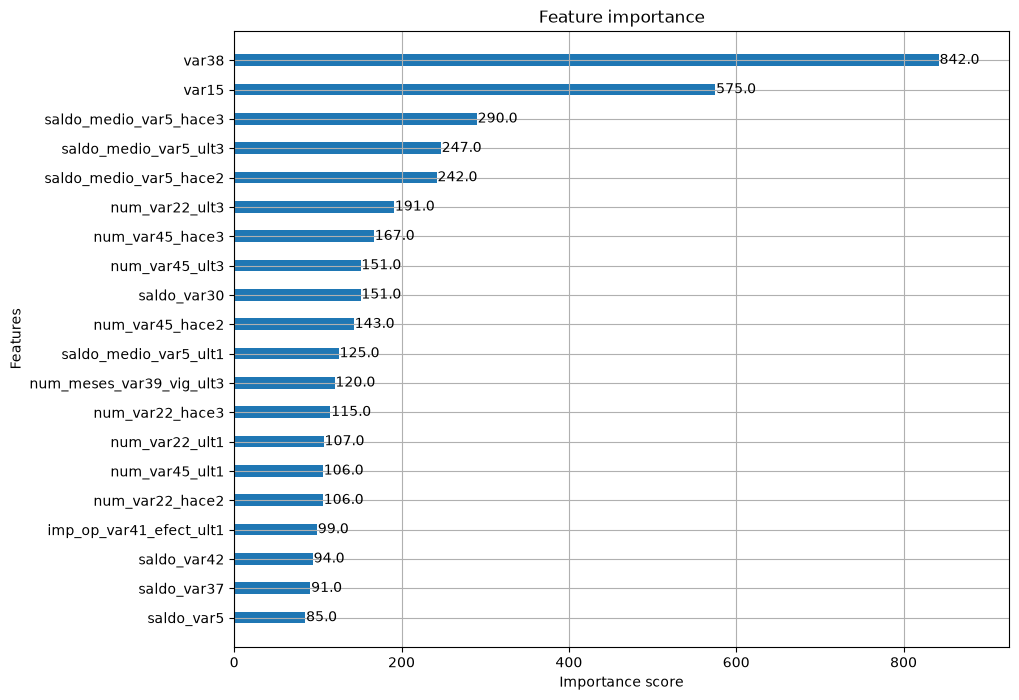

In [21]:
# xgboost에서 피처 중요도를 시각화하는 함수 plot_importance 임포트
from xgboost import plot_importance
# 그래프/시각화를 위한 matplotlib.pyplot 모듈 임포트
import matplotlib.pyplot as plt
# Jupyter Notebook에서 그래프를 노트북 셀 안에 바로 표시되도록 설정하는 매직 커맨드
%matplotlib inline


# plt.subplots() 파라미터 설명
#   - 1, 1        : 1행 1열, 즉 그래프(subplot)를 1개만 생성
#   - figsize=(10,8) : 그림(figure) 전체 크기를 가로 10, 세로 8(인치)로 지정
# fig : 전체 그림 객체, ax : 실제 그래프가 그려질 축(axes) 객체
fig, ax = plt.subplots(1,1,figsize=(10,8))

# plot_importance() 파라미터 설명
#   - xgb_clf              : 피처 중요도를 시각화할 학습된 XGBoost 모델
#   - ax=ax                 : 위에서 만든 axes 객체에 그래프를 그리도록 지정
#   - max_num_features=20   : 중요도가 높은 상위 20개 피처만 표시
#   - height=0.4            : 막대 그래프의 막대 두께(굵기) 지정
plot_importance(xgb_clf, ax=ax , max_num_features=20,height=0.4)

In [24]:
# early_stopping_rounds=100, eval_metric="auc"
# Lgbm 사용

# lightgbm에서 분류 모델 클래스(LGBMClassifier)와 콜백 함수 early_stopping, log_evaluation 임포트
from lightgbm import LGBMClassifier, early_stopping,log_evaluation
# AUC(ROC 곡선 아래 면적) 점수를 계산하는 함수 임포트
from sklearn.metrics import roc_auc_score

# LGBMClassifier() 파라미터 설명
#   - n_estimators=500 : 생성할 트리(부스팅 반복 횟수)의 최대 개수를 500으로 설정
lgbm_clf = LGBMClassifier(n_estimators=500)

# eval_set : 학습 중 매 반복마다 성능을 평가할 (입력, 정답) 데이터셋 목록
#   - (X_tr, y_tr)   : 학습 세트 자체의 성능도 함께 모니터링
#   - (X_val, y_val) : 검증 세트 성능을 모니터링 → early stopping 판단 기준으로 사용
eval_set=[(X_tr, y_tr), (X_val, y_val)]

# lgbm_clf.fit() 파라미터 설명
#   - X_tr, y_tr           : 실제 모델 학습에 사용되는 학습 데이터
#   - eval_metric="auc"    : 학습 중 평가할 성능 지표를 AUC로 지정
#   - eval_set=eval_set    : 위에서 정의한 평가용 데이터셋 목록 전달
#   - callbacks=[...]      : 학습 중 매 반복마다 실행할 콜백 함수 목록 (LightGBM 최신 버전은 early_stopping/verbose를 콜백 방식으로 처리)
lgbm_clf.fit(
        X_tr,
        y_tr,
        eval_metric="auc",
        eval_set=eval_set,
        callbacks=[
            # early_stopping(stopping_rounds=100) : 검증 세트 성능이 100번 연속 개선되지 않으면 학습을 조기 종료
            early_stopping(stopping_rounds=100),
            # log_evaluation(period=50) : 50번 반복마다 한 번씩 학습 로그(평가 결과)를 출력
            log_evaluation(period=50)
        ]
)

# lgbm_clf.predict_proba(X_test)[:, 1] : X_test에 대해 각 클래스 확률을 예측 후, 클래스 1(불만족)일 확률만 선택
predict_proba = lgbm_clf.predict_proba(X_test)[:, 1] # 1인 예측 확률,  class1
# roc_auc_score(y_test, predict_proba) : 실제 정답(y_test)과 예측 확률을 비교해 AUC 점수 계산
lgbm_roc_score = roc_auc_score(y_test, predict_proba)
# '{0:.4f}'.format(...) : 소수점 넷째 자리까지 반올림하여 LightGBM 모델의 AUC 점수 출력
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13308
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
[50]	training's auc: 0.916562	training's binary_logloss: 0.109711	valid_1's auc: 0.831734	valid_1's binary_logloss: 0.13536
[100]	training's auc: 0.936241	training's binary_logloss: 0.0993852	valid_1's auc: 0.830154	valid_1's binary_logloss: 0.136377
Early stopping, best iteration is:
[42]	training's auc: 0.91059	training's binary_logloss: 0.112183	valid_1's auc: 0.831787	vali

In [25]:
# hyperopt
# 1. search space 선언

# lgbm_search_space : LightGBM 하이퍼파라미터 튜닝을 위해 hyperopt가 탐색할 파라미터 공간을 딕셔너리로 정의
#   - key   : LGBMClassifier에 실제로 전달될 파라미터 이름
#   - value : hp.함수(라벨, ...)로 정의된 탐색 범위/분포
lgbm_search_space = {
                     # hp.quniform(label, low, high, q) : low~high 범위를 q 간격의 정수형 값으로 균등 탐색
                     #   - 'num_leaves' : 트리 하나가 가질 수 있는 최대 리프(잎) 노드 개수, 모델 복잡도를 조절
                     #   - 32, 64, 1    : 32부터 64까지 1씩 증가하며 탐색
                     'num_leaves': hp.quniform('num_leaves', 32, 64, 1),

                     # hp.quniform(label, low, high, q) : 1 간격의 정수형 값 탐색
                     #   - 'max_depth'  : 트리의 최대 깊이
                     #   - 100, 160, 1  : 100부터 160까지 1씩 증가하며 탐색 (LightGBM은 -1이 깊이 제한 없음을 의미하며 num_leaves로 복잡도를 더 많이 제어하기 때문에 큰 범위도 흔히 씀)
                     'max_depth': hp.quniform('max_depth', 100, 160, 1),

                     # hp.quniform(label, low, high, q) : 1 간격의 정수형 값 탐색
                     #   - 'min_child_samples' : 리프 노드가 되기 위해 필요한 최소 데이터(샘플) 개수, 과적합 방지용
                     #   - 60, 100, 1          : 60부터 100까지 1씩 증가하며 탐색
                     'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),

                     # hp.uniform(label, low, high) : low~high 범위에서 연속적인 실수값을 균등분포로 탐색
                     #   - 'subsample' : 트리 생성 시 사용할 데이터(행) 샘플링 비율
                     #   - 0.7, 1      : 70%~100% 사이 실수값 탐색
                     'subsample': hp.uniform('subsample', 0.7, 1),

                     # hp.uniform(label, low, high) : 연속 실수값 균등분포 탐색
                     #   - 'learning_rate' : 학습률(각 트리가 예측에 반영되는 정도)
                     #   - 0.01, 0.2       : 0.01~0.2 사이 실수값 탐색
                     'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
                    }

In [28]:
# def objective_func(search_space) : hyperopt의 fmin()이 반복 호출할 목적 함수 정의
#   - search_space : fmin() 실행 시 hp로 정의된 탐색 공간에서 뽑힌 하이퍼파라미터 값들이 딕셔너리 형태로 전달됨
def objective_func(search_space):
    # LGBMClassifier() 파라미터 설명
    #   - n_estimators=100                                  : 트리 개수 100개로 고정 (튜닝 대상 아님, 속도를 위해 작게 설정)
    #   - num_leaves=int(search_space['num_leaves'])         : search_space에서 뽑힌 num_leaves 값 사용 (hp.quniform은 float 반환하므로 int 형변환)
    #   - max_depth=int(search_space['max_depth'])           : search_space에서 뽑힌 max_depth 값 사용, int 형변환
    #   - min_child_samples=int(search_space['min_child_samples']) : search_space에서 뽑힌 값 사용, int 형변환
    #   - subsample=search_space['subsample']                 : search_space에서 뽑힌 값 그대로 사용 (이미 float)
    #   - learning_rate=search_space['learning_rate']         : search_space에서 뽑힌 값 그대로 사용
    lgbm_clf =  LGBMClassifier(n_estimators=100, num_leaves=int(search_space['num_leaves']),
                               max_depth=int(search_space['max_depth']),
                               min_child_samples=int(search_space['min_child_samples']),
                               subsample=search_space['subsample'],
                               learning_rate=search_space['learning_rate'])
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    # roc_auc_list : 각 fold별로 계산된 AUC 점수를 저장할 빈 리스트 초기화
    roc_auc_list = []
   
    # 3개 k-fold방식 적용
    # KFold(n_splits=3) : 데이터를 3개의 폴드(그룹)로 나눠 교차검증을 수행하도록 설정하는 객체 생성
    kf = KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    # kf.split(X_train) : X_train을 3등분하여, 매 반복마다 (학습용 인덱스, 검증용 인덱스) 쌍을 하나씩 반환 → 총 3번 반복
    for tr_index, val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index값으로 학습과 검증 데이터 세트 분리
        # X_train.iloc[tr_index], y_train.iloc[tr_index] : 이번 fold에서 학습용으로 쓸 인덱스에 해당하는 행 선택
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        # X_train.iloc[val_index], y_train.iloc[val_index] : 이번 fold에서 검증용으로 쓸 인덱스에 해당하는 행 선택
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]


        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행.
        # lgbm_clf.fit() 파라미터 설명
        #   - X_tr, y_tr                        : 이번 fold의 학습용 데이터로 실제 학습 수행
        #   - callbacks=[early_stopping(30)]     : 검증 성능이 30회 연속 개선 없으면 조기 종료
        #   - eval_metric="auc"                  : 평가 지표를 AUC로 지정
        #   - eval_set=[(X_tr, y_tr), (X_val, y_val)] : 학습/검증 세트 성능을 매 반복마다 모니터링
        lgbm_clf.fit(X_tr, y_tr, callbacks=[early_stopping(30)], eval_metric="auc",
           eval_set=[(X_tr, y_tr), (X_val, y_val)])


        # 1로 예측한 확률값 추출후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결과값 담음.
        # lgbm_clf.predict_proba(X_val)[:, 1] : 검증 세트에 대해 클래스 1일 확률만 추출
        # roc_auc_score(y_val, ...) : 실제 정답(y_val)과 예측 확률을 비교해 AUC 점수 계산
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:, 1])
        # roc_auc_list.append(score) : 이번 fold의 AUC 점수를 리스트에 추가
        roc_auc_list.append(score)
   
    # 3개 k-fold로 계산된 roc_auc값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최소값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환.
    # np.mean(roc_auc_list) : 3개 fold의 AUC 점수 평균 계산
    # -1을 곱하는 이유: hyperopt의 fmin()은 값을 "최소화"하는 방향으로 탐색하므로,
    #                  AUC는 클수록 좋은 지표이기 때문에 부호를 뒤집어 "최소화 = AUC 최대화"가 되도록 맞춤
    return -1*np.mean(roc_auc_list)

In [30]:
# hyperopt에서 최적화 실행 함수(fmin), TPE 알고리즘(tpe), 시도 기록 클래스(Trials) 임포트
from hyperopt import fmin, tpe, Trials


# Trials() : fmin() 실행 중 매 시도(trial)마다의 하이퍼파라미터 값, 점수, 상태 등을 기록/저장하는 객체 생성
#   → 나중에 전체 탐색 히스토리를 분석하거나 재사용할 때 사용
trials = Trials()


# fmin()함수를 호출. max_evals지정된 횟수만큼 반복 후 목적함수의 최소값을 가지는 최적 입력값 추출.

# fmin() 파라미터 설명
#   - fn=objective_func       : 최소화할 목적 함수 (LightGBM용, 하이퍼파라미터를 받아 -AUC 평균값을 반환)
#   - space=lgbm_search_space : 앞서 정의한 LightGBM 하이퍼파라미터 탐색 공간(딕셔너리)
#   - algo=tpe.suggest        : 탐색 알고리즘으로 TPE(Tree-structured Parzen Estimator, 베이지안 최적화 기법의 일종) 사용
#   - max_evals=50            : 목적 함수를 최대 50번 호출(50번의 하이퍼파라미터 조합 시도)하며 탐색
#   - trials=trials           : 위에서 만든 Trials 객체에 각 시도 결과를 기록
#   - rstate=np.random.default_rng(seed=30) : 탐색 과정의 무작위성을 제어하는 난수 생성기, seed 고정으로 재실행 시 동일 결과 재현
best = fmin(fn=objective_func, space=lgbm_search_space, algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trials, rstate=np.random.default_rng(seed=30))


# best : fmin()이 찾아낸, 목적 함수 값(-AUC 평균)을 최소로 만드는(=AUC를 최대로 만드는) 최적의 LightGBM 하이퍼파라미터 조합(딕셔너리)
print('best:', best)

[LightGBM] [Info] Number of positive: 1579, number of negative: 38965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12827                    
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 192
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872
[LightGBM] [Info] Start training from score -3.205872 
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[98]	training's auc: 0.88765	training's binary_logloss: 0.121808	valid_1's auc: 0.831519	valid_1's binary_logloss: 0.135868
[LightGBM] [Info] Number of positive: 1609, number of negative: 38935
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memor

In [32]:
# LGBMClassifier() 파라미터 설명
#   - n_estimators=500                          : 튜닝 때(100)보다 트리 개수를 늘려 최종 모델의 성능을 끌어올림
#   - num_leaves=int(best['num_leaves'])         : fmin()이 찾은 최적 num_leaves 값 사용 (hp.quniform은 float 반환하므로 int 형변환)
#   - max_depth=int(best['max_depth'])           : 최적 max_depth 값 사용, int 형변환
#   - min_child_samples=int(best['min_child_samples']) : 최적 min_child_samples 값 사용, int 형변환
#   - subsample=round(best['subsample'], 5)      : 최적 subsample 값 사용, 소수점 5자리까지 반올림
#   - learning_rate=round(best['learning_rate'], 5) : 최적 learning_rate 값 사용, 소수점 5자리까지 반올림
#   - early_stopping_rounds=100                  : 검증 성능이 100회 연속 개선 없으면 조기 종료 (최종 학습이므로 튜닝 때(30)보다 넉넉하게 설정)
#   - eval_metric="auc"                          : 평가 지표를 AUC로 지정
lgbm_clf =  LGBMClassifier(n_estimators=500, num_leaves=int(best['num_leaves']),
                           max_depth=int(best['max_depth']),
                           min_child_samples=int(best['min_child_samples']),
                           subsample=round(best['subsample'], 5),
                           learning_rate=round(best['learning_rate'], 5),
                           early_stopping_rounds=100,
                           eval_metric="auc",
                          )


# evaluation metric을 auc로, early stopping은 100 으로 설정하고 학습 수행.

# lgbm_clf.fit() 파라미터 설명
#   - X_tr, y_tr    : 실제 모델 학습에 사용되는 학습 데이터 (앞서 만들어둔 학습용 세트 재사용)
#   - eval_set=[(X_tr, y_tr), (X_val, y_val)] : 학습 중 매 반복마다 학습/검증 세트 성능을 함께 모니터링 (조기 종료 판단용)
lgbm_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])


# roc_auc_score() 파라미터 설명
#   - y_test : 실제 정답 레이블 (최종 평가용, 학습/검증에 전혀 쓰이지 않은 데이터)
#   - lgbm_clf.predict_proba(X_test)[:,1] : X_test에 대한 클래스 1(불만족) 확률만 추출
lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])

# '{0:.4f}'.format(...) : 소수점 넷째 자리까지 반올림하여 최종 튜닝된 LightGBM 모델의 AUC 점수 출력
print('ROC AUC --> : {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13001
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 202
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stoppin